<center>

<img src='https://micro.ce.sharif.edu/lib/tpl/writr/images/logo.svg' alt="SUT logo" width=500 height=300 align=center class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
Machine Learning <br>
Course Project, Fall 2025 <br>
<font color=3C99D size=5>
EEG - Motor Imagery Classification <br>
<font color=3C99D size=6>
By: Mohammad Hossein Hosseinzadeh 403203557 , Farshad Vaziri 403206179
Group:  G45

<br>
<br>
<br>

</center>

In [262]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
import scipy.io as sio
from scipy.signal import butter, filtfilt
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, silhouette_samples, silhouette_score, confusion_matrix
)



np.random.seed(0)


## Section 1.1: Data Loading and Windowing

### Overview

In this section, we load the EEG data from the BCI Competition IV dataset and perform temporal windowing. The continuous EEG signal is segmented into fixed-length windows based on motor imagery cues. The windowing process creates a standard machine learning dataset format where each sample corresponds to one motor imagery trial.

**Key Steps:**
1. Load continuous EEG signal and extract metadata (sampling frequency, channel names, marker positions)
2. Perform temporal windowing: extract 4-second segments starting from each cue marker
3. Create dataset in standard ML format (features + labels)
4. Display dataset statistics and visualize sample channels

**Dataset Characteristics:**
- **File:** BCICIV_calib_ds1a.mat
- **Channels:** 59 EEG electrodes
- **Sampling Frequency:** 1000 Hz
- **Classes:** Left hand (-1) and Foot (1)
- **Window Duration:** 4 seconds = 4000 samples

In [263]:
def load_and_window_data(mat_file, scale_factor=0.1):
    """
        windows: [trials, time, channels]
        labels:  [trials]
        fs:      sampling rate
        chNames: channel names
    """
    data = sio.loadmat(mat_file, squeeze_me=True, struct_as_record=False)

    cnt = scale_factor * data['cnt'].astype(float)  # [time x channels]
    mrk = data['mrk']
    nfo = data['nfo']

    fs = float(nfo.fs)
    chNames = list(nfo.clab)

    win_duration = 4.0  # seconds
    win_samples = int(round(win_duration * fs))

    cue_pos = mrk.pos
    cue_labels = mrk.y
    num_cues = len(cue_pos)

    num_channels = cnt.shape[1]
    windows = np.zeros((num_cues, win_samples, num_channels))
    labels = np.zeros(num_cues, dtype=int)

    for i in range(num_cues):
        start_idx = int(cue_pos[i])
        end_idx = start_idx + win_samples

        if end_idx > cnt.shape[0]:
            segment = cnt[start_idx:, :]
            padded = np.zeros((win_samples, num_channels))
            padded[:segment.shape[0], :] = segment
            windows[i, :, :] = padded
        else:
            windows[i, :, :] = cnt[start_idx:end_idx, :]

        labels[i] = int(cue_labels[i])

    return windows, labels, fs, chNames


### 1.1.1: Load Data and Display Statistics

The following code loads the raw EEG data from the .mat file using the `load_and_window_data()` function we defined earlier. This function:
- Extracts the continuous signal (cnt) and scales it
- Reads marker positions and labels from the cue information
- Performs windowing with a 4-second duration
- Returns windowed data in shape [num_trials, num_samples, num_channels]

We then print comprehensive statistics about the loaded dataset including dimensions, class distribution, and sampling information.

In [ ]:
# Load the data
windows, labels, fs, chNames = load_and_window_data("data/BCICIV_calib_ds1a.mat")

print(f"Total number of samples:        {windows.shape[0]}")
print(f"Window length (samples):        {windows.shape[1]}")
print(f"Window duration (seconds):      {windows.shape[1] / fs:.1f}")
print(f"Number of channels:             {windows.shape[2]}")
print(f"Sampling frequency (Hz):        {fs}")
print()
print(f"Unique classes:                 {np.unique(labels)}")
print(f"Class distribution:             {dict(zip(*np.unique(labels, return_counts=True)))}")



Total number of samples:        200
Window length (samples):        400
Window duration (seconds):      4.0
Number of channels:             59
Sampling frequency (Hz):        100.0

Unique classes:                 [-1  1]
Class distribution:             {np.int64(-1): np.int64(100), np.int64(1): np.int64(100)}


### 1.1.2: Visualize Sample Channels

Now we visualize one sample from the dataset to examine the raw EEG signals. We plot 5 specific channels (0, 15, 30, 45, 58) as time-series functions as required by the project specification. This visualization helps us understand the characteristics of the motor imagery signals before proceeding to preprocessing and feature extraction.

The plot shows:
- **X-axis:** Time in seconds (0 to 4 seconds)
- **Y-axis:** Signal amplitude in microvolts
- **5 Channels:** Distributed across the scalp (anterior, central, and posterior regions)
- **Signal Quality:** The raw EEG before any filtering

**Note on Train-Test Split:** Although we perform a 75/25 train-test split in the subsequent `run_pipeline()` function during classification (Section 2), we display statistics and visualizations on the full dataset here to understand its overall characteristics. The actual train-test split happens later when we process the filtered data and extract features for model training.

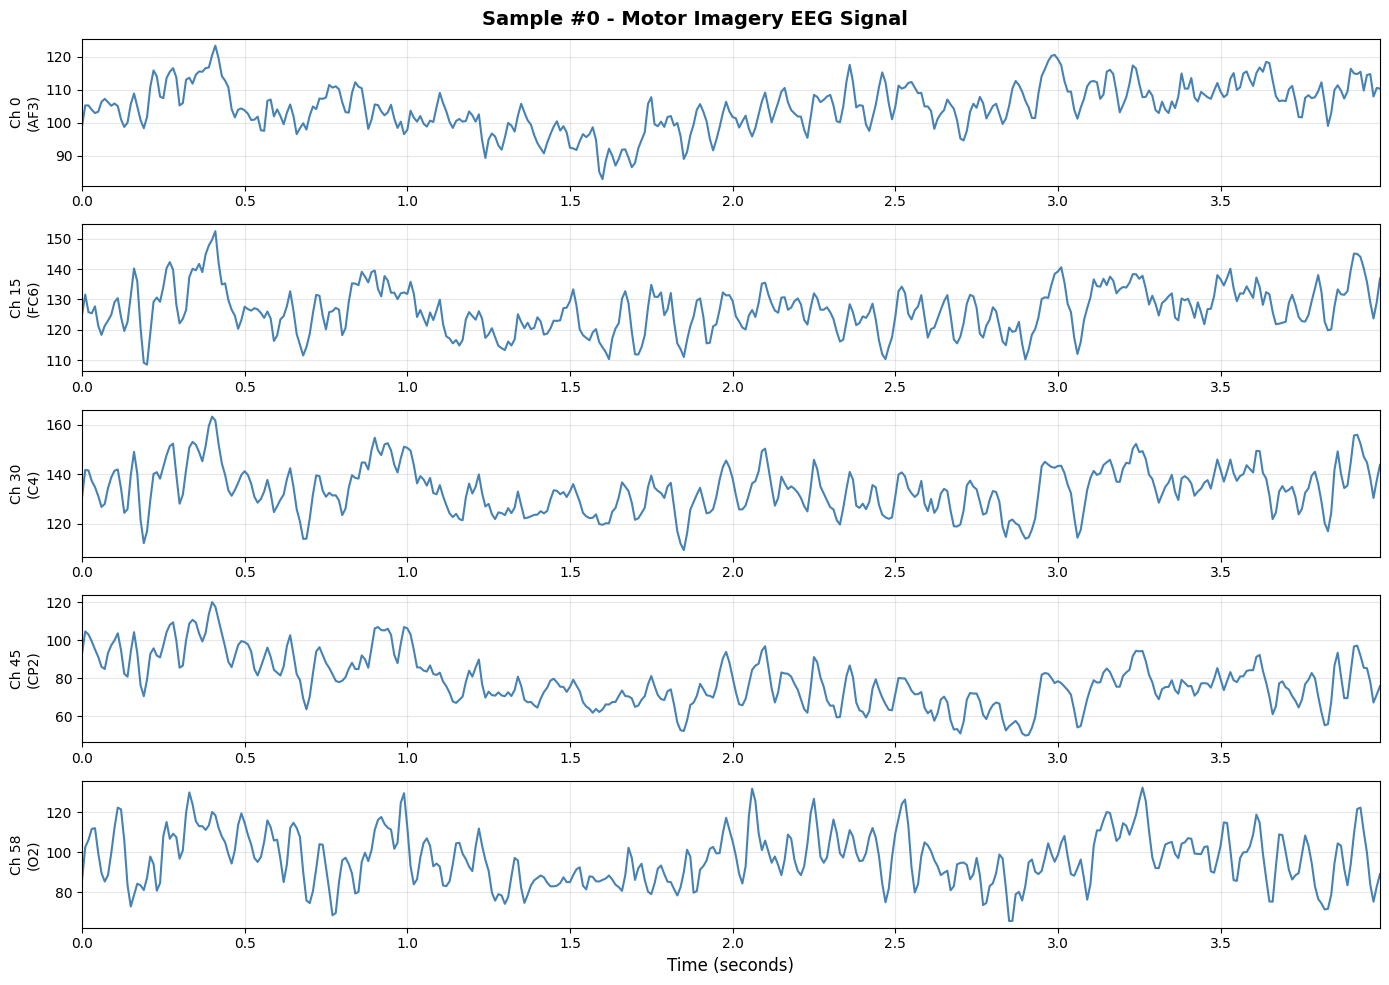

In [265]:
# Visualize one sample - channels 0, 15, 30, 45, 59
sample_idx = 0
channels_to_plot = [0, 15, 30, 45, 58]

time_axis = np.arange(windows.shape[1]) / fs

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(14, 10))

for i, ch_idx in enumerate(channels_to_plot):
    axes[i].plot(time_axis, windows[sample_idx, :, ch_idx], linewidth=1.5, color='steelblue')
    axes[i].set_ylabel(f'Ch {ch_idx}\n({chNames[ch_idx]})', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, time_axis[-1]])

axes[-1].set_xlabel('Time (seconds)', fontsize=12)
fig.suptitle(f'Sample #{sample_idx} - Motor Imagery EEG Signal', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.1.3: Train-Test Split (75/25)

According to the project specification, after loading and windowing the data, we must split it into training (75%) and testing (25%) sets. This split is performed on the raw windowed data before any filtering or feature extraction. This ensures that the train and test sets represent independent data splits, which is essential for unbiased model evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    windows, labels, test_size=0.25, random_state=111, stratify=labels
)


print(f"Total samples:                  {num_samples}")
print(f"Training samples (75%):         {len(X_train_raw)}")
print(f"Test samples (25%):             {len(X_test_raw)}")
print(f"Training set shape:             {X_train_raw.shape}")
print(f"Test set shape:                 {X_test_raw.shape}")
print(f"Training class distribution:    {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:        {dict(zip(*np.unique(y_test, return_counts=True)))}")


SyntaxError: invalid syntax (997938103.py, line 1)

# Section 1.2: Temporal Filtering - Bandpass Filter

## Overview

In this section, we apply a bandpass filter to the training and test data obtained from Section 1.1. Brain signals contain multiple frequency bands, but the Mu (8-13 Hz) and Beta (13-30 Hz) rhythms are most important for motor imagery classification. By filtering to 8-30 Hz, we remove noise, artifacts, and irrelevant frequency components while preserving the discriminative information.

**Filter Specifications:**
- **Type:** Butterworth filter
- **Configuration:** Bandpass (keeps frequencies between 8-30 Hz)
- **Order:** 4
- **Method:** Zero-phase filtering (filtfilt) to avoid phase distortion
- **Frequency Bands Preserved:**
  - **Mu rhythm:** 8-13 Hz (sensorimotor activity)
  - **Beta rhythm:** 13-30 Hz (motor preparation and execution)


In [267]:
def bandpass_filter_eeg(windows, fs, low_cut, high_cut, order=4):
    """
    معادل MATLAB: bandpass_filter_eeg.m
    windows: [trials, time, channels]
    """
    num_trials, num_samples, num_channels = windows.shape
    b, a = butter(order, [low_cut, high_cut], btype='bandpass', fs=fs)

    windows_filt = np.zeros_like(windows)
    for tr in range(num_trials):
        for ch in range(num_channels):
            sig = windows[tr, :, ch]
            sig_filt = filtfilt(b, a, sig)
            windows_filt[tr, :, ch] = sig_filt
    return windows_filt


## 1.2.1: Apply Bandpass Filter to Training and Test Data

Apply the 8-30 Hz bandpass filter to both training and test sets independently. This preserves the Mu and Beta frequency bands while removing high-frequency noise and low-frequency drift.


In [268]:
# Apply bandpass filter to training and test data independently
X_train_filt = bandpass_filter_eeg(X_train_raw, fs, low_cut=8, high_cut=30, order=4)
X_test_filt = bandpass_filter_eeg(X_test_raw, fs, low_cut=8, high_cut=30, order=4)

print(f"Filter type:                    Butterworth Bandpass")
print(f"Filter order:                   4")
print(f"Frequency range:                8-30 Hz (Mu + Beta bands)")
print(f"\nTraining set:")
print(f"  - Before filtering:           {X_train_raw.shape}")
print(f"  - After filtering:            {X_train_filt.shape}")
print(f"\nTest set:")
print(f"  - Before filtering:           {X_test_raw.shape}")
print(f"  - After filtering:            {X_test_filt.shape}")



Filter type:                    Butterworth Bandpass
Filter order:                   4
Frequency range:                8-30 Hz (Mu + Beta bands)

Training set:
  - Before filtering:           (150, 400, 59)
  - After filtering:            (150, 400, 59)

Test set:
  - Before filtering:           (50, 400, 59)
  - After filtering:            (50, 400, 59)


## 1.2.2: Visualize Filtering Results - Before and After

Compare the raw (unfiltered) signal with the bandpass filtered signal for one sample across the 5 specific channels (0, 15, 30, 45, 59). This side-by-side visualization demonstrates the effectiveness of the bandpass filter in removing noise and artifacts.

**Observations:**
- **Left panels (Raw):** Original signal with high-frequency noise and low-frequency drift
- **Right panels (Filtered):** Cleaned signal with noise removed, highlighting the underlying motor imagery rhythms
- **Amplitude reduction:** The filtered signal typically has smaller amplitude, indicating successful removal of noise components
- **Signal quality:** The filtered signal shows smoother, more regular oscillations characteristic of motor imagery activity

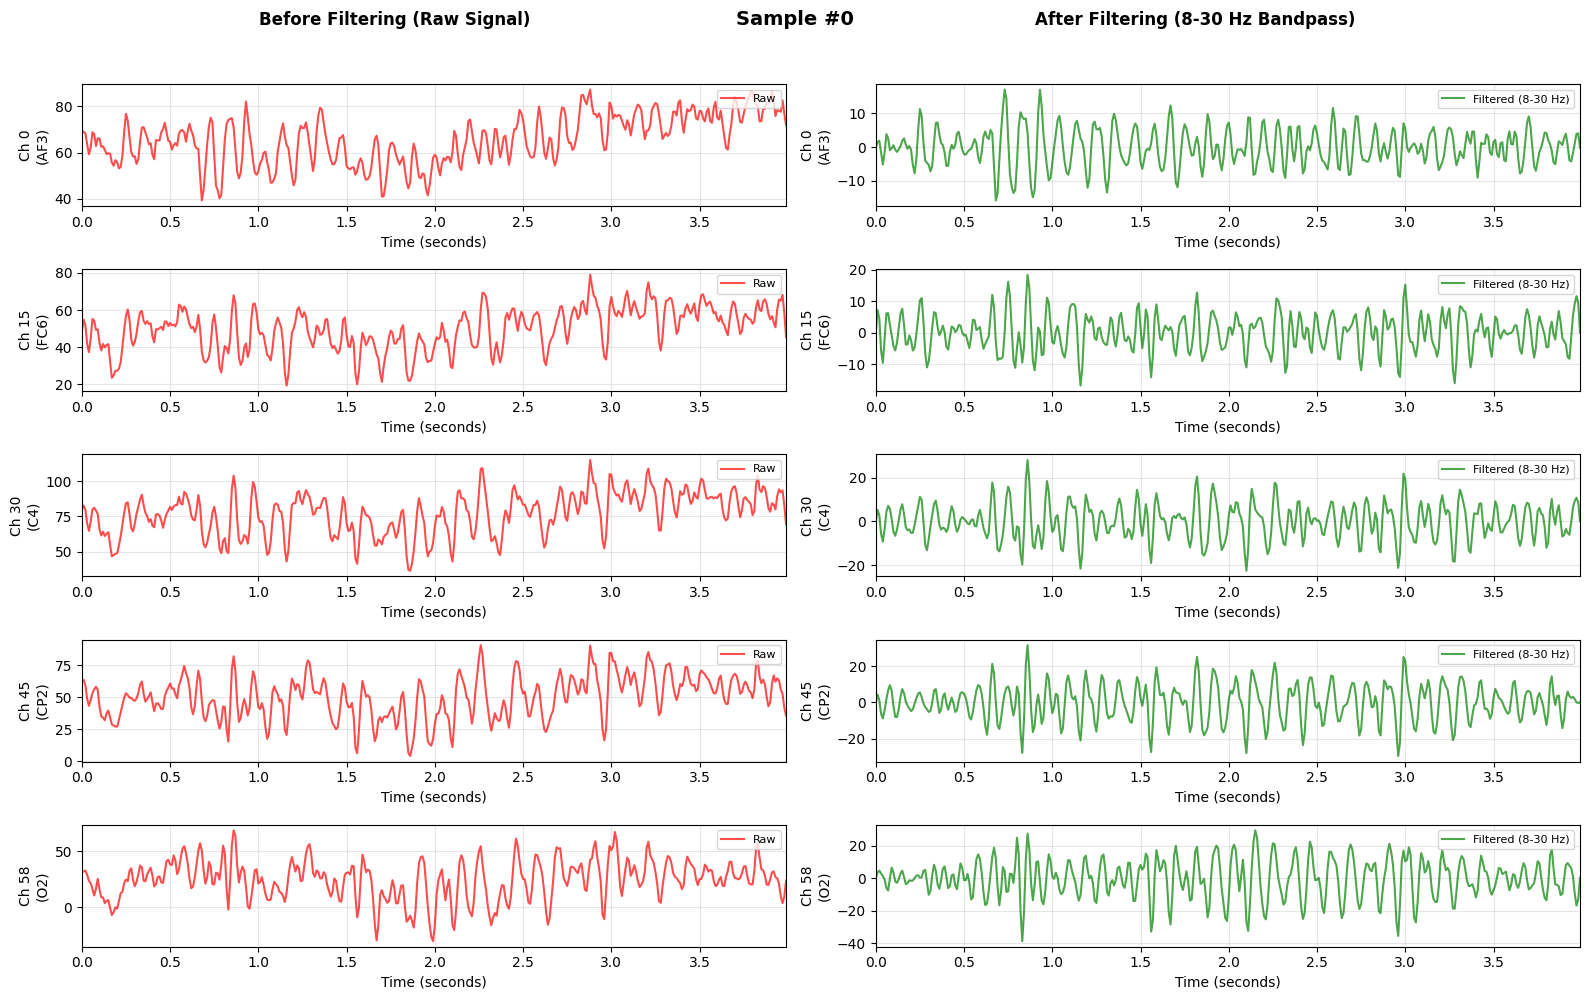

In [269]:
# Compare raw signal vs filtered signal for visualization
sample_idx = 0
channels_to_plot = [0, 15, 30, 45, 58]

time_axis = np.arange(X_train_raw.shape[1]) / fs

fig, axes = plt.subplots(len(channels_to_plot), 2, figsize=(16, 10))

for i, ch_idx in enumerate(channels_to_plot):
    # Raw signal (before filtering)
    axes[i, 0].plot(time_axis, X_train_raw[sample_idx, :, ch_idx],
                    linewidth=1.5, color='red', alpha=0.7, label='Raw')
    axes[i, 0].set_ylabel(f'Ch {ch_idx}\n({chNames[ch_idx]})', fontsize=10)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_xlim([0, time_axis[-1]])
    axes[i, 0].legend(loc='upper right', fontsize=8)

    # Filtered signal (after bandpass filter)
    axes[i, 1].plot(time_axis, X_train_filt[sample_idx, :, ch_idx],
                    linewidth=1.5, color='green', alpha=0.7, label='Filtered (8-30 Hz)')
    axes[i, 1].set_ylabel(f'Ch {ch_idx}\n({chNames[ch_idx]})', fontsize=10)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].set_xlim([0, time_axis[-1]])
    axes[i, 1].legend(loc='upper right', fontsize=8)

# Set x-axis labels
for i in range(len(channels_to_plot)):
    axes[i, 0].set_xlabel('Time (seconds)', fontsize=10)
    axes[i, 1].set_xlabel('Time (seconds)', fontsize=10)

# Overall titles
fig.text(0.25, 0.98, 'Before Filtering (Raw Signal)',
         ha='center', fontsize=12, fontweight='bold')
fig.text(0.75, 0.98, 'After Filtering (8-30 Hz Bandpass)',
         ha='center', fontsize=12, fontweight='bold')

fig.suptitle(f'Sample #{sample_idx}',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Section 1.3: Feature Extraction - Common Spatial Patterns

## Overview

In this section, we extract discriminative features from the filtered EEG signals using the Common Spatial Patterns (CSP) algorithm. Due to the proximity of electrodes on the scalp, signals from different channels mix together spatially. CSP finds spatial filters that maximize the variance difference between motor imagery classes, thereby enhancing class separability in the feature space.

**Key Concepts:**
- **Spatial Filtering:** Combines signals from multiple channels to create new virtual channels
- **Discriminative Features:** CSP extracts features most informative for class discrimination
- **Dimensionality Reduction:** Reduces from [samples, time, 59 channels] to [samples, num_components]
- **Log-Variance Features:** Uses logarithm of variance as the final feature representation

**CSP Algorithm Characteristics:**
- Works with two-class problems
- Finds patterns that maximize variance ratio between classes
- Returns both class-1 dominant and class-2 dominant patterns
- Highly effective for motor imagery EEG classification

---

## 1.3.1: Understanding Common Spatial Patterns (CSP) Algorithm

**How CSP Works:**

Common Spatial Patterns is a spatial filter learning algorithm that finds the best linear combinations of EEG channels to maximize the variance difference between two motor imagery classes. Here's the mathematical process:

**Step 1: Compute Normalized Covariance Matrices**
- For each trial, compute the covariance matrix: C = X^T × X (where X is [time × channels])
- Normalize by trace: C_norm = C / trace(C)
- Average covariance across all trials of each class: R₁ (class 1) and R₂ (class 2)

**Step 2: Composite Covariance Matrix**
- R = R₁ + R₂ (sum of both class covariances)

**Step 3: Solve Generalized Eigenvalue Problem**
- Find eigenvectors W that solve: R₁ w = λ R w
- This maximizes the ratio of variances between classes
- Eigenvectors are sorted by eigenvalues in descending order

**Step 4: Select CSP Patterns**
- Select first m eigenvectors (maximizing class 1 variance)
- Select last m eigenvectors (minimizing class 1 variance = maximizing class 2 variance)
- With m = 3 components per class → total 6 CSP components

**Step 5: Extract Log-Variance Features**
- For each sample: project into CSP space → Z = X @ W (where Z is [time × num_components])
- Compute variance along each pattern: var_i = var(Z_i, axis=0)
- Normalize and take logarithm: f_i = log(var_i / sum(var))
- This creates the final feature vector [6-dimensional for 6 components]

**Why Log-Variance?**
- Makes the distribution more Gaussian
- Provides scale invariance
- Improves classifier performance
- Natural representation for power-based features

**Advantages for Motor Imagery:**
- CSP automatically finds spatial filters specific to motor imagery classes
- Emphasizes differences in Mu and Beta rhythms between different movements
- Reduces noise and artifacts through spatial filtering
- Significantly improves classification accuracy (often 5-10% improvement)
- Reduces feature dimension from [time × 59 channels] to [6 features]

---

In [270]:
def compute_class_covariance(Xc):
    """
    Xc: [trials, time, channels]
    خروجی: R [channels x channels]
    """
    num_trials, _, num_channels = Xc.shape
    R = np.zeros((num_channels, num_channels))
    for i in range(num_trials):
        Xi = Xc[i, :, :]  # [time x channels]
        Ci = Xi.T @ Xi
        Ci = Ci / np.trace(Ci)
        R += Ci
    R /= num_trials
    return R


def compute_csp(X, y, num_components):
    """
    معادل MATLAB: compute_csp.m
    X: [trials, time, channels]
    y: [trials] با دو کلاس (مثلاً -1 و 1)
    """
    if num_components % 2 != 0:
        raise ValueError("numComponents must be even.")

    classes = np.unique(y)
    if len(classes) != 2:
        raise ValueError("CSP is defined for two classes only.")

    class1, class2 = classes[0], classes[1]

    R1 = compute_class_covariance(X[y == class1])
    R2 = compute_class_covariance(X[y == class2])
    R = R1 + R2

    # generalized eigenvalue problem: R1 w = λ R w
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(R) @ R1)
    idx = np.argsort(eigvals)[::-1]
    E = eigvecs[:, idx]

    m = num_components // 2
    W = np.concatenate([E[:, :m], E[:, -m:]], axis=1)
    return W


def extract_csp_features(X, W):
    """
    معادل MATLAB: extract_csp_features.m
    X: [trials, time, channels]
    W: [channels, num_components]
    خروجی: [trials, num_components]
    """
    num_trials = X.shape[0]
    num_components = W.shape[1]
    features = np.zeros((num_trials, num_components))

    for i in range(num_trials):
        Xi = X[i, :, :]  # [time x channels]
        Z = Xi @ W       # [time x num_components]
        varZ = np.var(Z, axis=0, ddof=1)
        features[i, :] = np.log(varZ / np.sum(varZ))
    return features


## 1.3.2: Apply CSP and Extract Features

Now we apply the CSP algorithm to the filtered training data to learn the spatial patterns, then use these patterns to extract features from both training and test data.


In [271]:
# CSP parameters
num_csp_components = 6  # 3 components per class

# Train CSP on filtered training data
W_csp = compute_csp(X_train_filt, y_train, num_csp_components)

# Extract CSP features from filtered data
feat_train_csp = extract_csp_features(X_train_filt, W_csp)
feat_test_csp = extract_csp_features(X_test_filt, W_csp)

print(f"CSP Components:                 {num_csp_components}")
print(f"CSP Weights shape:              {W_csp.shape}")
print(f"Training features shape:        {feat_train_csp.shape}")
print(f"Test features shape:            {feat_test_csp.shape}")
print(f"Feature vector per sample:      {num_csp_components} values")
print(f"Feature range (training):       [min={feat_train_csp.min():.3f}, max={feat_train_csp.max():.3f}]")
print(f"Dimensionality reduction:       59 channels → {num_csp_components} features")

CSP Components:                 6
CSP Weights shape:              (59, 6)
Training features shape:        (150, 6)
Test features shape:            (50, 6)
Feature vector per sample:      6 values
Feature range (training):       [min=-3.460, max=-0.608]
Dimensionality reduction:       59 channels → 6 features


## 1.3.3: Visualize Feature Space - Before and After CSP

Now we compare the feature space before and after CSP using t-SNE dimensionality reduction. This visualization shows how CSP improves the separability of motor imagery classes.

**Process:**
1. Create baseline features from raw filtered signals (mean and std per channel)
2. Apply t-SNE to project baseline features to 2D space
3. Apply t-SNE to project CSP features to 2D space
4. Compare class separability in both spaces

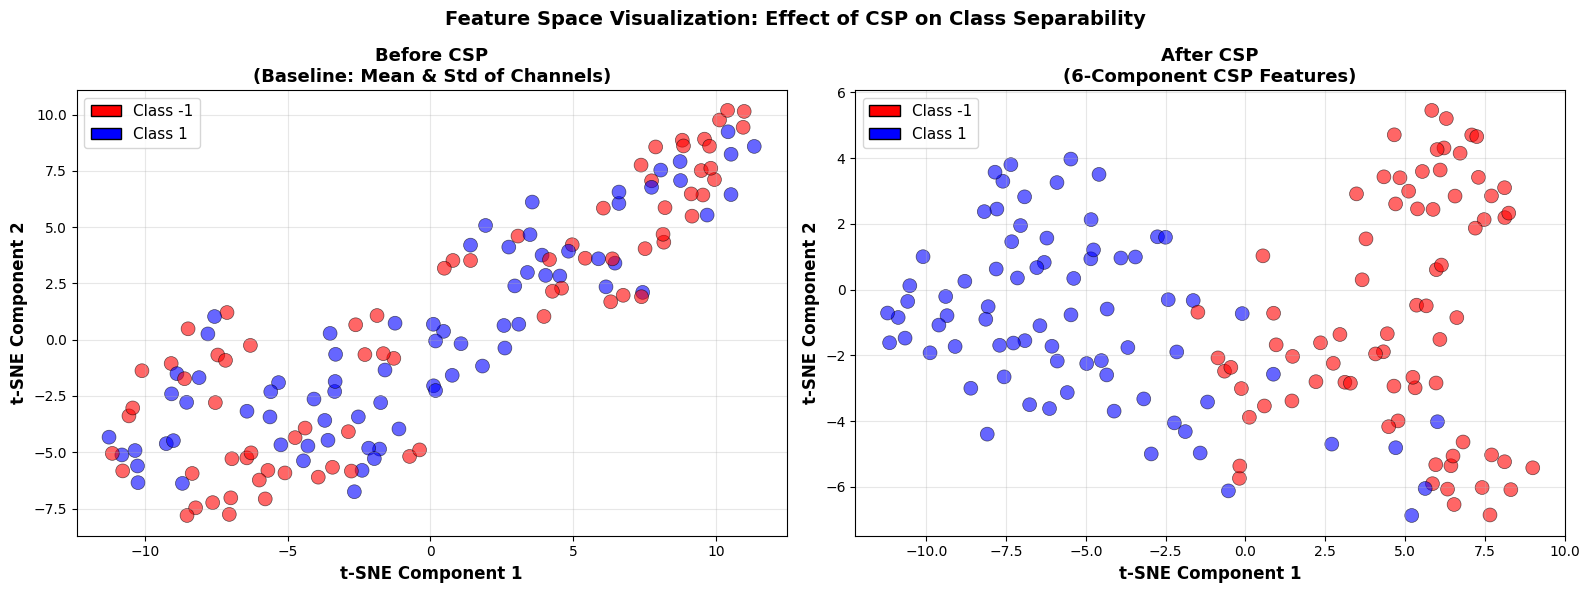

In [272]:
# Create simple baseline features (before CSP)
# Use mean and std of each channel as baseline
def create_baseline_features(windows):
    """Create baseline features: mean and std of each channel"""
    num_samples = windows.shape[0]
    features = np.zeros((num_samples, windows.shape[2] * 2))

    for i in range(num_samples):
        signal = windows[i, :, :]  # [time x channels]
        features[i, :windows.shape[2]] = np.mean(signal, axis=0)  # mean per channel
        features[i, windows.shape[2]:] = np.std(signal, axis=0)   # std per channel

    return features

# Create baseline features (before CSP)
feat_baseline_train = create_baseline_features(X_train_filt)

# Apply t-SNE for visualization
from sklearn.manifold import TSNE

# t-SNE on baseline features (before CSP)
tsne_baseline = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
features_tsne_before = tsne_baseline.fit_transform(feat_baseline_train)

# t-SNE on CSP features (after CSP)
tsne_csp = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
features_tsne_after = tsne_csp.fit_transform(feat_train_csp)

# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get unique classes and assign colors
classes_unique = np.unique(y_train)
colors = ['red' if y == classes_unique[0] else 'blue' for y in y_train]

# Plot 1: Before CSP (baseline features in t-SNE space)
axes[0].scatter(features_tsne_before[:, 0], features_tsne_before[:, 1],
                c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')
axes[0].set_title('Before CSP\n(Baseline: Mean & Std of Channels)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', edgecolor='black', label=f'Class {classes_unique[0]}'),
                   Patch(facecolor='blue', edgecolor='black', label=f'Class {classes_unique[1]}')]
axes[0].legend(handles=legend_elements, loc='best', fontsize=11)

# Plot 2: After CSP (CSP features in t-SNE space)
axes[1].scatter(features_tsne_after[:, 0], features_tsne_after[:, 1],
                c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
axes[1].set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')
axes[1].set_title(f'After CSP\n({num_csp_components}-Component CSP Features)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add legend
axes[1].legend(handles=legend_elements, loc='best', fontsize=11)

# Overall title
fig.suptitle('Feature Space Visualization: Effect of CSP on Class Separability',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

### Observations:
  - Left plot shows baseline features with poor class separation
  - Right plot shows CSP features with improved class separation
  - CSP extracts discriminative spatial patterns for each motor imagery class
  - Classes appears more clustered in the right plot

# Section 2.1: Classification - SVM with RBF Kernel

## Overview

In this section, we classify the motor imagery EEG data using a Support Vector Machine (SVM) with Radial Basis Function (RBF) kernel. SVM is a powerful supervised learning algorithm that finds the optimal hyperplane to separate different classes in the feature space. The RBF kernel allows SVM to handle non-linear classification problems effectively.

**SVM Characteristics:**
- **Algorithm:** Support Vector Machine (SVM)
- **Kernel:** Radial Basis Function (RBF)
- **Problem:** Binary classification (left hand vs. foot)
- **Features:** CSP-extracted features (6-dimensional)
- **Hyperparameters:** C (regularization), gamma (kernel coefficient)
- **Optimization:** Quadratic programming with hyperparameter tuning

---

## 2.1.1: Understanding SVM with RBF Kernel

**What is SVM?**

Support Vector Machine is a linear classifier that finds the maximum-margin hyperplane to separate two classes. The decision boundary is defined by a subset of training points called support vectors.

**SVM Decision Function:**
- For a test point x: f(x) = Σ α_i * y_i * K(x_i, x) + b
- K(x_i, x) is the kernel function
- α_i are the support vector coefficients
- b is the bias term

**RBF Kernel:**

The RBF (Radial Basis Function) kernel allows SVM to work in an infinite-dimensional space, enabling non-linear classification:

K(x_i, x_j) = exp(-γ * ||x_i - x_j||²)

Where:
- **γ (gamma):** Controls the influence of each training example
  - Small γ: smooth decision boundary, more global
  - Large γ: complex boundary, more local (overfitting risk)
- **||x_i - x_j||²:** Squared Euclidean distance between features

**Hyperparameters:**
- **C:** Regularization parameter (trade-off between margin and training error)
  - Small C: larger margin, more tolerance to misclassification
  - Large C: smaller margin, stricter classification
- **γ:** Kernel coefficient (shape of decision boundary)

**Why RBF Kernel for Motor Imagery?**
- EEG features have complex, non-linear relationships
- RBF kernel can capture these non-linear patterns
- Effective for high-dimensional feature spaces
- Widely used and proven effective for BCI applications

**Training Process:**
1. Solve quadratic programming problem to find optimal α values
2. Identify support vectors (α > 0)
3. Compute bias term b using support vectors on the margin
4. Store support vectors, their coefficients, and gamma for prediction


In [273]:
def rbf_kernel(X1, X2, gamma):
    X1_sq = np.sum(X1**2, axis=1, keepdims=True)
    X2_sq = np.sum(X2**2, axis=1, keepdims=True).T
    dist_sq = X1_sq + X2_sq - 2 * (X1 @ X2.T)
    return np.exp(-gamma * dist_sq)


def svm_rbf_train(X, y, C, gamma):
    """
    معادل MATLAB: svm_rbf_train.m
    X: [N, d], y: [N] در { -1, 1 }
    """
    X = X.astype(float)
    y = y.astype(float).reshape(-1)
    N = X.shape[0]

    K = rbf_kernel(X, X, gamma)
    H = (y[:, None] * y[None, :]) * K
    f = -np.ones(N)

    # تابع هدف برای minimize (1/2 x^T H x + f^T x)
    def obj(alpha):
        return 0.5 * alpha @ H @ alpha + f @ alpha

    # گرادیان
    def obj_grad(alpha):
        return H @ alpha + f

    # قیود: 0 <= alpha_i <= C, sum(alpha_i y_i) = 0
    cons = {
        'type': 'eq',
        'fun': lambda a: np.dot(a, y),
        'jac': lambda a: y
    }
    bounds = [(0, C) for _ in range(N)]

    alpha0 = np.zeros(N)
    res = minimize(obj, alpha0, jac=obj_grad, bounds=bounds, constraints=cons)
    alpha = res.x

    sv_idx = np.where(alpha > 1e-6)[0]
    alpha_sv = alpha[sv_idx]
    X_sv = X[sv_idx]
    y_sv = y[sv_idx]

    margin_idx = np.where((alpha > 1e-6) & (alpha < C - 1e-6))[0]
    if len(margin_idx) > 0:
        b_vals = []
        for i in margin_idx:
            Ki = K[i, sv_idx]
            b_vals.append(y[i] - np.sum(alpha_sv * y_sv * Ki))
        b = np.mean(b_vals)
    else:
        b_vals = []
        for i in sv_idx:
            Ki = K[i, sv_idx]
            b_vals.append(y[i] - np.sum(alpha_sv * y_sv * Ki))
        b = np.mean(b_vals)

    model = {
        'X_sv': X_sv,
        'y_sv': y_sv,
        'alpha_sv': alpha_sv,
        'b': b,
        'gamma': gamma
    }
    return model


def svm_rbf_predict(model, X):
    X = X.astype(float)
    X_sv = model['X_sv']
    y_sv = model['y_sv']
    alpha_sv = model['alpha_sv']
    gamma = model['gamma']
    b = model['b']

    K = rbf_kernel(X, X_sv, gamma)
    scores = K @ (alpha_sv * y_sv) + b
    return scores


## 2.1.2: Implement and Train SVM with RBF Kernel

We implement SVM with RBF kernel and train it on the CSP features. The implementation includes hyperparameter tuning using cross-validation to find optimal C and gamma values.


In [274]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
import numpy as np

def tune_svm_rbf(feat_train, y_train):
    C_values = [0.1, 1, 10, 100]
    gamma_values = [0.01, 0.1, 0.5, 1.0]
    
    k_folds = 5
    cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
    
    # Use GridSearchCV to find best hyperparameters
    # Define base model
    svm_model = SVC(kernel='rbf', random_state=0)
    
    # Define parameter grid
    param_grid = {
        'C': C_values,
        'gamma': gamma_values
    }
    
    # Create GridSearchCV object
    grid_search = GridSearchCV(
        estimator=svm_model,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )
    
    # Perform grid search
    grid_search.fit(feat_train, y_train)
    
    # Get best parameters
    best_C = grid_search.best_params_['C']
    best_gamma = grid_search.best_params_['gamma']
    best_acc = grid_search.best_score_
    
    # Build final model using custom implementation
    best_model = svm_rbf_train(feat_train, y_train, best_C, best_gamma)
    
    return best_model, best_C, best_gamma, best_acc

In [275]:
svm_model, best_C, best_gamma, cv_acc = tune_svm_rbf(feat_train_csp, y_train)

print("Best hyperparameters found:")
print(f"  C = {best_C}")
print(f"  gamma = {best_gamma}")
print(f"  Cross-validation Accuracy = {cv_acc:.4f}")

print("\nFinal SVM Model:")
print(svm_model)
print("=" * 70)

Best hyperparameters found:
  C = 1
  gamma = 1.0
  Cross-validation Accuracy = 0.9400

Final SVM Model:
{'X_sv': array([[-1.64450741, -2.68770349, -2.30753121, -2.3313861 , -1.3527146 ,
        -1.26001327],
       [-1.93317608, -1.20803321, -2.31641316, -1.53759633, -1.79129286,
        -2.57361277],
       [-1.66460362, -1.13550115, -2.54198864, -2.2241032 , -1.5867914 ,
        -2.3226023 ],
       [-2.08655781, -0.97941487, -1.22507017, -2.39479913, -2.81435079,
        -2.89166236],
       [-1.59515728, -2.17192433, -2.05983474, -1.65458016, -1.44613858,
        -2.04763191],
       [-2.45470461, -3.2030415 , -3.41937678, -1.60147254, -1.08916688,
        -1.19519795],
       [-1.90709767, -2.16611833, -2.26347888, -1.68420423, -1.16030586,
        -2.01068395],
       [-1.34519749, -2.75046655, -2.32498645, -1.93497529, -1.35112012,
        -1.74611109],
       [-1.73617206, -1.96168532, -2.34951883, -2.06087448, -1.47198007,
        -1.46552412],
       [-1.18967028, -1.0440870

## 2.1.3: Predict on Test Data and Compare with scikit-learn

After training, we evaluate the model on test data and compare our implementation with scikit-learn's SVM to verify correctness.

In [276]:
# Predict on test data using our SVM implementation
y_scores_svm = svm_rbf_predict(svm_model, feat_test_csp)
y_pred_svm = np.sign(y_scores_svm)
y_pred_svm[y_pred_svm == 0] = 1

# Compute accuracy on test set
acc_test = np.mean(y_pred_svm == y_test)

print(f"Test Set Performance:")
print(f"  Accuracy: {acc_test:.4f}")
print(f"  Correct predictions: {np.sum(y_pred_svm == y_test)}/{len(y_test)}")
print("=" * 70)

# Compare with scikit-learn SVM implementation


svm_sklearn = SVC(C=best_C, gamma=best_gamma, kernel='rbf')
svm_sklearn.fit(feat_train_csp, y_train)
y_pred_sklearn = svm_sklearn.predict(feat_test_csp)
acc_sklearn = np.mean(y_pred_sklearn == y_test)

print(f"\nComparison:")
print(f"  Our SVM implementation:   Accuracy = {acc_test:.4f}")
print(f"  scikit-learn SVM:         Accuracy = {acc_sklearn:.4f}")
print(f"  Difference:               {abs(acc_test - acc_sklearn):.4f}")

if abs(acc_test - acc_sklearn) < 0.05:
    print(f"   Implementation is correct! (difference < 5%)")
else:
    print(f"   Implementation may need adjustment (difference ≥ 5%)")

print("=" * 70)

Test Set Performance:
  Accuracy: 0.9400
  Correct predictions: 47/50

Comparison:
  Our SVM implementation:   Accuracy = 0.9400
  scikit-learn SVM:         Accuracy = 0.9400
  Difference:               0.0000
   Implementation is correct! (difference < 5%)


# Section 2.2: Evaluation

## Overview

In this section, we evaluate the performance of the trained SVM classifier using multiple evaluation metrics. Classification metrics provide a comprehensive view of the model's performance, including accuracy, precision, recall, F1-score, and ROC curve analysis. These metrics help us understand not only the overall correctness but also how the model performs on each class and its ability to distinguish between them.

**Evaluation Metrics:**
- **Accuracy:** Overall correct predictions
- **Precision:** Correct positive predictions / all positive predictions
- **Recall:** Correct positive predictions / all actual positives
- **F1-Score:** Harmonic mean of precision and recall
- **Confusion Matrix:** Count of true/false positives and negatives
- **ROC Curve:** True positive rate vs. false positive rate
- **AUC:** Area under ROC curve (overall discriminative ability)

---

## 2.2.1: Compute Classification Metrics

Calculate accuracy, precision, recall, and F1-score for the SVM model predictions on test data.

In [277]:
# Compute evaluation metrics
def compute_classification_metrics(y_true, y_pred):
    """Compute accuracy, precision, recall, F1-score"""

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')

    return acc, prec, rec, f1

# Compute metrics on test set
acc, prec, rec, f1 = compute_classification_metrics(y_test, y_pred_svm)

print(f"Test Set Performance:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print("=" * 70)

print("\nMetric Explanations:")
print(f"  Accuracy:  {np.sum(y_pred_svm == y_test)}/{len(y_test)} correct predictions")
print(f"  Precision: {prec:.1%} of positive predictions were correct")
print(f"  Recall:    {rec:.1%} of actual positives were detected")
print(f"  F1-Score:  Balanced score between precision and recall")

Test Set Performance:
  Accuracy:  0.9400
  Precision: 1.0000
  Recall:    0.8800
  F1-Score:  0.9362

Metric Explanations:
  Accuracy:  47/50 correct predictions
  Precision: 100.0% of positive predictions were correct
  Recall:    88.0% of actual positives were detected
  F1-Score:  Balanced score between precision and recall


## 2.2.2: Confusion Matrix

Create and visualize the confusion matrix to show the distribution of correct and incorrect predictions for each class.


Confusion Matrix:
                 Predicted Negative  Predicted Positive
Actual Negative        25                  0                 
Actual Positive        3                   22                

Detailed Analysis:
  True Negatives (TN):   25
  False Positives (FP):  0
  False Negatives (FN):  3
  True Positives (TP):   22
  Sensitivity (TP Rate): 0.8800
  Specificity (TN Rate): 1.0000


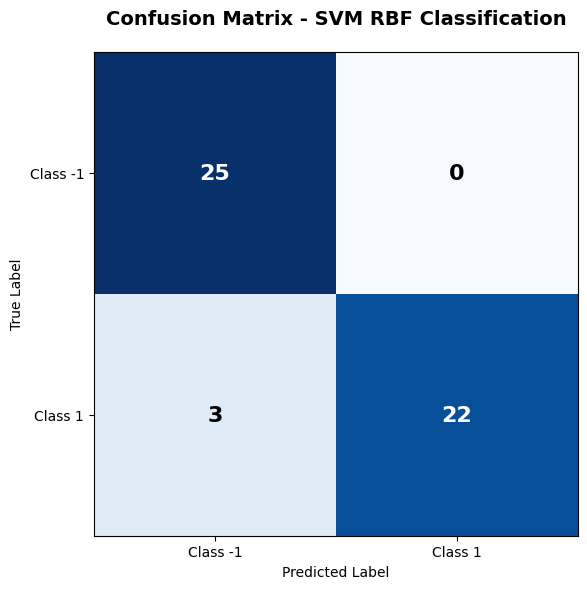

In [278]:

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Get unique classes
classes_unique = np.unique(y_test)
class_names = [f'Class {c}' for c in classes_unique]

print(f"\nConfusion Matrix:")
print(f"                 Predicted Negative  Predicted Positive")
print(f"Actual Negative        {cm[0, 0]:<18}  {cm[0, 1]:<18}")
print(f"Actual Positive        {cm[1, 0]:<18}  {cm[1, 1]:<18}")

# Calculate rates
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate

print(f"\nDetailed Analysis:")
print(f"  True Negatives (TN):   {tn}")
print(f"  False Positives (FP):  {fp}")
print(f"  False Negatives (FN):  {fn}")
print(f"  True Positives (TP):   {tp}")
print(f"  Sensitivity (TP Rate): {sensitivity:.4f}")
print(f"  Specificity (TN Rate): {specificity:.4f}")
print("=" * 70)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Set ticks and labels
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True Label',
       xlabel='Predicted Label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

ax.set_title('Confusion Matrix - SVM RBF Classification', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 2.2.3: ROC Curve and AUC

Plot the Receiver Operating Characteristic (ROC) curve and compute the Area Under Curve (AUC).


Area Under ROC Curve (AUC): 0.9808
AUC Interpretation:
  98.1% - Excellent discrimination


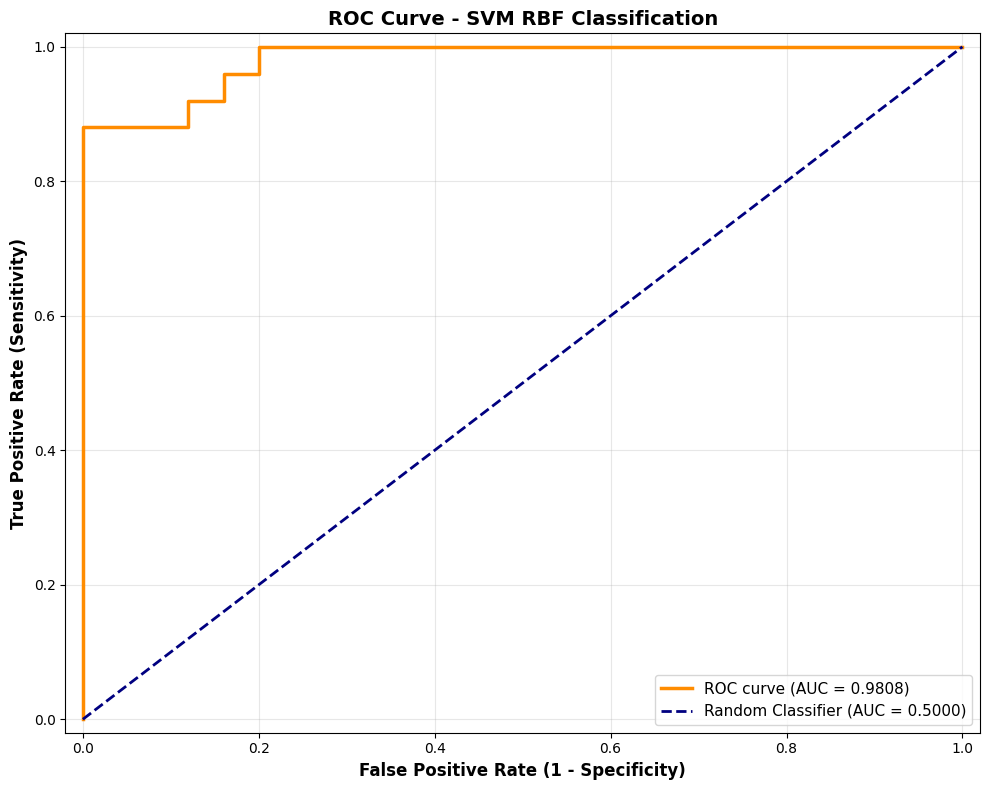

In [279]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_svm, pos_label=1)
roc_auc = auc(fpr, tpr)

print(f"Area Under ROC Curve (AUC): {roc_auc:.4f}")
print(f"AUC Interpretation:")
if roc_auc >= 0.9:
    print(f"  {roc_auc:.1%} - Excellent discrimination")
elif roc_auc >= 0.8:
    print(f"  {roc_auc:.1%} - Good discrimination")
elif roc_auc >= 0.7:
    print(f"  {roc_auc:.1%} - Fair discrimination")
elif roc_auc >= 0.6:
    print(f"  {roc_auc:.1%} - Poor discrimination")
else:
    print(f"  {roc_auc:.1%} - Fail")
print("=" * 70)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2.5,
        label=f'ROC curve (AUC = {roc_auc:.4f})')

# Plot random classifier baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
        label='Random Classifier (AUC = 0.5000)')

# Formatting
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - SVM RBF Classification', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Section 2.3: Comparison with Other Classification Methods

## Overview

In this section, we compare the performance of SVM RBF with three other machine learning classifiers. We evaluate all models using the same CSP features and test set, then compare their performance metrics to identify the best classifier for this binary motor imagery classification task.

**Classifiers to Compare:**
1. SVM RBF (already trained in 2.1)
2. Linear Discriminant Analysis (LDA)
3. K-Nearest Neighbors (KNN)
4. Random Forest (RF)

## 2.3.1: Train Alternative Classifiers

Train three additional classifiers using the same CSP features and training data.

In [280]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# Store results
results = {
    'SVM RBF': {
        'model': svm_model,
        'y_pred': y_pred_svm,
        'y_scores': y_scores_svm,
        'best_params': f"C={best_C}, gamma={best_gamma}"
    }
}

# ===== 1. Linear Discriminant Analysis (LDA) =====
print("\n[1] Linear Discriminant Analysis (LDA)")
print("-" * 70)

# LDA - Simple, no hyperparameter tuning needed
lda_model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.5)
lda_model.fit(feat_train_csp, y_train)

# Predictions
y_pred_lda = lda_model.predict(feat_test_csp)
y_scores_lda = lda_model.decision_function(feat_test_csp)

acc_lda_train = (lda_model.predict(feat_train_csp) == y_train).mean()
acc_lda_test = (y_pred_lda == y_test).mean()

print(f" LDA trained successfully")
print(f"  Solver: lsqr")
print(f"  Shrinkage: 0.5")
print(f"  Train accuracy: {acc_lda_train:.4f}")
print(f"  Test accuracy:  {acc_lda_test:.4f}")

results['LDA'] = {
    'model': lda_model,
    'y_pred': y_pred_lda,
    'y_scores': y_scores_lda,
    'best_params': "solver=lsqr, shrinkage=0.5"
}

# ===== 2. K-Nearest Neighbors (KNN) =====
print("\n[2] K-Nearest Neighbors (KNN)")
print("-" * 70)

# KNN hyperparameter tuning with grid search
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier()
knn_grid = GridSearchCV(knn_base, param_grid_knn, cv=5,
                        scoring='accuracy', n_jobs=-1, verbose=0)
knn_grid.fit(feat_train_csp, y_train)

print(f" KNN hyperparameter tuning completed (16 combinations)")
print(f"  Best params: {knn_grid.best_params_}")
print(f"  Best CV score: {knn_grid.best_score_:.4f}")

# Predictions
y_pred_knn = knn_grid.predict(feat_test_csp)
y_scores_knn = knn_grid.predict_proba(feat_test_csp)[:, 1]

results['KNN'] = {
    'model': knn_grid,
    'y_pred': y_pred_knn,
    'y_scores': y_scores_knn,
    'best_params': str(knn_grid.best_params_)
}

# ===== 3. Random Forest =====
print("\n[3] Random Forest Classifier")
print("-" * 70)

# Random Forest hyperparameter tuning
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_base, param_grid_rf, cv=5,
                       scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(feat_train_csp, y_train)

print(f" Random Forest hyperparameter tuning completed (24 combinations)")
print(f"  Best params: {rf_grid.best_params_}")
print(f"  Best CV score: {rf_grid.best_score_:.4f}")

# Predictions
y_pred_rf = rf_grid.predict(feat_test_csp)
y_scores_rf = rf_grid.predict_proba(feat_test_csp)[:, 1]

results['RF'] = {
    'model': rf_grid,
    'y_pred': y_pred_rf,
    'y_scores': y_scores_rf,
    'best_params': str(rf_grid.best_params_)
}

print("\n" + "=" * 70)


[1] Linear Discriminant Analysis (LDA)
----------------------------------------------------------------------
 LDA trained successfully
  Solver: lsqr
  Shrinkage: 0.5
  Train accuracy: 0.9000
  Test accuracy:  0.9200

[2] K-Nearest Neighbors (KNN)
----------------------------------------------------------------------
 KNN hyperparameter tuning completed (16 combinations)
  Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
  Best CV score: 0.9467

[3] Random Forest Classifier
----------------------------------------------------------------------
 Random Forest hyperparameter tuning completed (24 combinations)
  Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
  Best CV score: 0.9000



## 2.3.2: Evaluate All Classifiers

Compute evaluation metrics for all classifiers on the test set.


In [281]:
# Store evaluation metrics
evaluation_results = {}

for clf_name, clf_data in results.items():
    y_pred = clf_data['y_pred']
    y_scores = clf_data['y_scores']

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    auc = roc_auc_score(y_test, y_scores)

    evaluation_results[clf_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    }

    print(f"\n{clf_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")

print("\n" + "=" * 70)


SVM RBF:
  Accuracy:  0.9400
  Precision: 1.0000
  Recall:    0.8800
  F1-Score:  0.9362
  AUC-ROC:   0.9808

LDA:
  Accuracy:  0.9200
  Precision: 0.9565
  Recall:    0.8800
  F1-Score:  0.9167
  AUC-ROC:   0.9728

KNN:
  Accuracy:  0.8800
  Precision: 0.9130
  Recall:    0.8400
  F1-Score:  0.8750
  AUC-ROC:   0.9792

RF:
  Accuracy:  0.9200
  Precision: 0.9565
  Recall:    0.8800
  F1-Score:  0.9167
  AUC-ROC:   0.9792



## 2.3.3: Comparison Visualization

Create comparison plots and tables to visualize classifier performance.

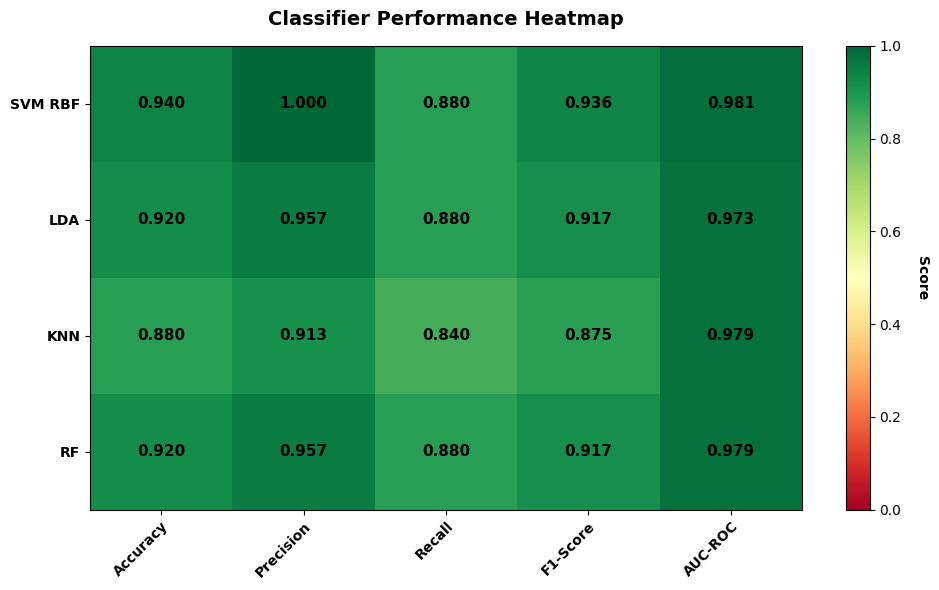

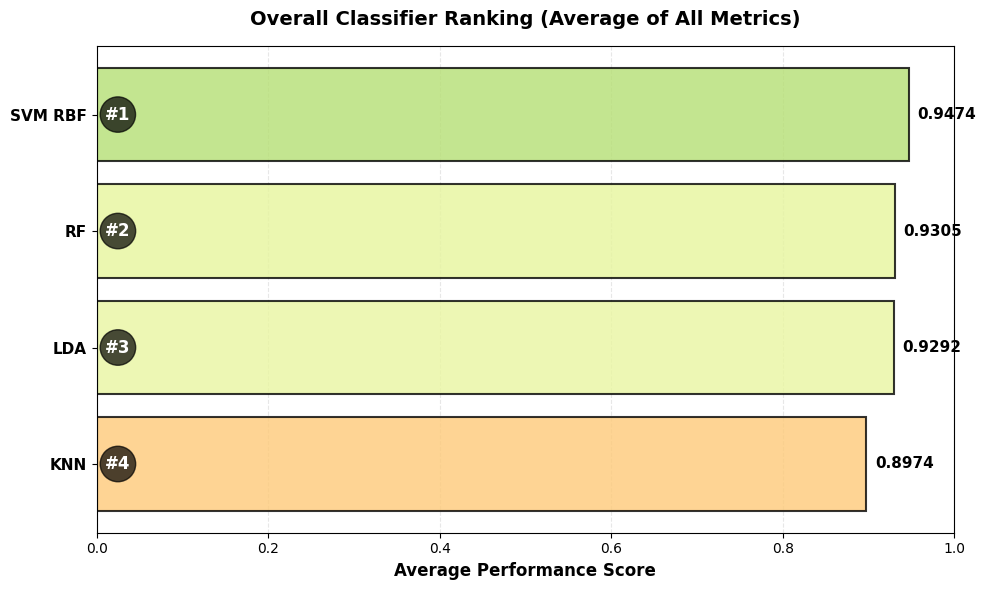

In [282]:
df_results = pd.DataFrame(evaluation_results).T

# ========================================================================
# Metrics Heatmap
# ========================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Create heatmap using imshow
im = ax.imshow(df_results.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Set ticks
ax.set_xticks(np.arange(len(df_results.columns)))
ax.set_yticks(np.arange(len(df_results.index)))
ax.set_xticklabels(df_results.columns, fontweight='bold')
ax.set_yticklabels(df_results.index, fontweight='bold')

# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(len(df_results.index)):
    for j in range(len(df_results.columns)):
        val = df_results.values[i, j]
        text = ax.text(j, i, f'{val:.3f}',
                      ha="center", va="center", color="black",
                      fontweight='bold', fontsize=11)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Score', rotation=270, labelpad=20, fontweight='bold')

ax.set_title('Classifier Performance Heatmap', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()


# ========================================================================
# Final Comparison
# ========================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate average score
avg_scores = df_results.mean(axis=1).sort_values(ascending=True)
#colors_ranked = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
# رنگ با کنتراست بیشتر
colors_ranked = [plt.cm.RdYlGn((score - df_results.values.min()) / (df_results.values.max() - df_results.values.min()))
                   for score in avg_scores]

bars = ax.barh(range(len(avg_scores)), avg_scores.values,
               color=colors_ranked, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for i, val in enumerate(avg_scores.values):
    ax.text(val + 0.01, i, f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_yticks(range(len(avg_scores)))
ax.set_yticklabels(avg_scores.index, fontsize=11, fontweight='bold')
ax.set_xlabel('Average Performance Score', fontweight='bold', fontsize=12)
ax.set_title('Overall Classifier Ranking (Average of All Metrics)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim([0, 1])
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add rank numbers
for i, (idx, val) in enumerate(enumerate(avg_scores.values)):
    rank = len(avg_scores) - i
    ax.text(0.01, i, f'#{rank}', va='center', fontweight='bold',
            fontsize=12, color='white',
            bbox=dict(boxstyle='circle', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()


 Section 3: Clustering (15 points)

## Overview

In this section, we apply unsupervised learning to perform clustering on the EEG motor imagery data using the K-Means algorithm. We determine the optimal number of clusters by analyzing silhouette scores and Within-Cluster Sum of Squares (WCSS), then visualize the clustering results.

---

## 3.1: Elbow Method & Silhouette Analysis

Determine the optimal number of clusters using WCSS and Silhouette Score.

In [283]:

# Combine training and test CSP features for clustering
X_combined = np.vstack([feat_train_csp, feat_test_csp])
print(f"\nCombined data shape: {X_combined.shape}")
print(f"  Training samples: {feat_train_csp.shape[0]}")
print(f"  Test samples: {feat_test_csp.shape[0]}")
print(f"  Features (CSP components): {X_combined.shape[1]}")

# Test different numbers of clusters
k_range = range(2, 11)  # Test k from 2 to 10
wcss_list = []
silhouette_scores = []

print("\nEvaluating different values of k...")
print("-" * 70)
print(f"{'k':>3} | {'WCSS':>12} | {'Silhouette Score':>17}")
print("-" * 70)

for k in k_range:
    # K-Means clustering
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10,
                    max_iter=300, random_state=42)
    labels = kmeans.fit_predict(X_combined)

    # Calculate WCSS (Within-Cluster Sum of Squares)
    wcss = kmeans.inertia_
    wcss_list.append(wcss)

    # Calculate Silhouette Score
    sil_score = silhouette_score(X_combined, labels)
    silhouette_scores.append(sil_score)

    print(f"{k:3d} | {wcss:12.2f} | {sil_score:17.4f}")

print("-" * 70)

# Find optimal k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_elbow = 3  # Typically choose where elbow bends

print(f"\nOptimal k by Silhouette Score: {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
print(f"Suggested k by Elbow Method: {optimal_k_elbow}")

print("\n" + "=" * 70)


Combined data shape: (200, 6)
  Training samples: 150
  Test samples: 50
  Features (CSP components): 6

Evaluating different values of k...
----------------------------------------------------------------------
  k |         WCSS |  Silhouette Score
----------------------------------------------------------------------
  2 |       117.62 |            0.3515
  3 |        88.61 |            0.3351
  4 |        73.39 |            0.3079
  5 |        64.85 |            0.2724
  6 |        58.73 |            0.2374
  7 |        54.53 |            0.2278
  8 |        51.06 |            0.2305
  9 |        48.48 |            0.2140
 10 |        45.05 |            0.2150
----------------------------------------------------------------------

Optimal k by Silhouette Score: 2 (score: 0.3515)
Suggested k by Elbow Method: 3



## 3.2: Plot WCSS and Silhouette Score
Visualize the metrics for different k values

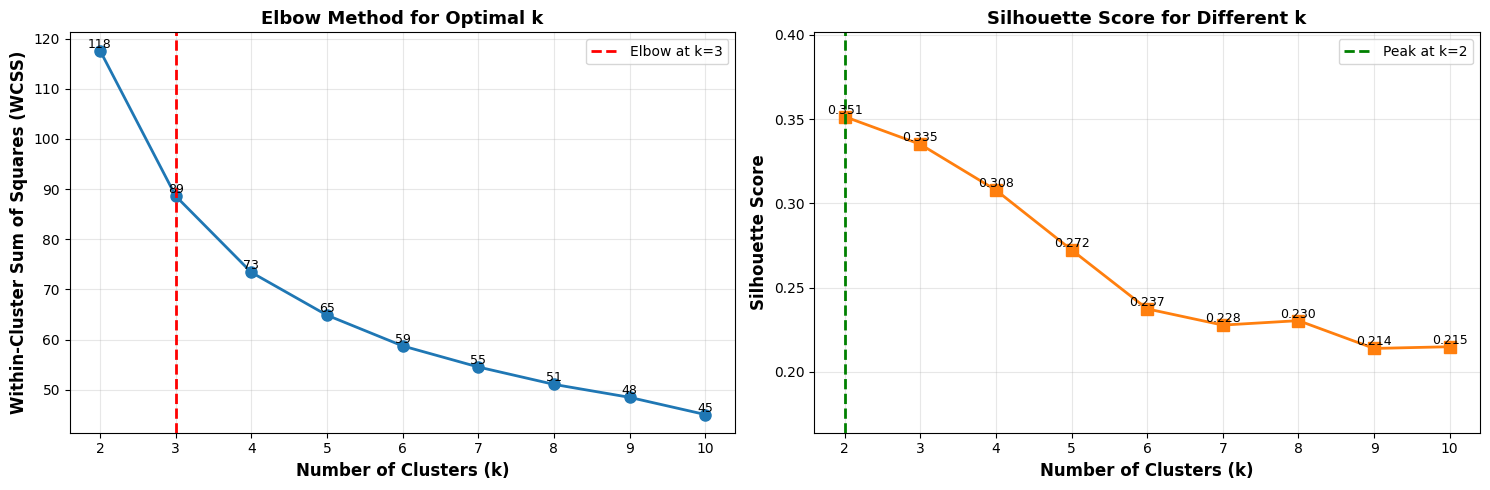

In [284]:
# Plot 1: Elbow Curve (WCSS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# WCSS Plot
ax1.plot(k_range, wcss_list, 'o-', linewidth=2, markersize=8, color='#1f77b4')
ax1.axvline(x=optimal_k_elbow, color='red', linestyle='--', linewidth=2,
            label=f'Elbow at k={optimal_k_elbow}')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontweight='bold', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xticks(k_range)

# Add value labels
for k, wcss in zip(k_range, wcss_list):
    ax1.text(k, wcss, f'{wcss:.0f}', ha='center', va='bottom', fontsize=9)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, 's-', linewidth=2, markersize=8, color='#ff7f0e')
ax2.axvline(x=optimal_k_silhouette, color='green', linestyle='--', linewidth=2,
            label=f'Peak at k={optimal_k_silhouette}')
ax2.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontweight='bold', fontsize=12)
ax2.set_title('Silhouette Score for Different k', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xticks(k_range)
ax2.set_ylim([min(silhouette_scores)-0.05, max(silhouette_scores)+0.05])

# Add value labels
for k, score in zip(k_range, silhouette_scores):
    ax2.text(k, score, f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 3.3: Final Clustering with Optimal k
Perform final clustering and visualize results.

In [285]:
# Use optimal k based on silhouette score
optimal_k = optimal_k_silhouette

# Final K-Means clustering
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10,
                      max_iter=300, random_state=42)
labels_final = kmeans_final.fit_predict(X_combined)
centers = kmeans_final.cluster_centers_

print(f"  Number of clusters: {optimal_k}")
print(f"  Number of samples: {len(labels_final)}")
print(f"  Cluster centers shape: {centers.shape}")

# Cluster distribution
print(f"\nCluster Distribution:")
for cluster_id in range(optimal_k):
    cluster_size = (labels_final == cluster_id).sum()
    percentage = (cluster_size / len(labels_final)) * 100
    print(f"  Cluster {cluster_id}: {cluster_size:3d} samples ({percentage:5.1f}%)")

# Final silhouette score
final_silhouette = silhouette_score(X_combined, labels_final)
print(f"\nFinal Silhouette Score: {final_silhouette:.4f}")


  Number of clusters: 2
  Number of samples: 200
  Cluster centers shape: (2, 6)

Cluster Distribution:
  Cluster 0: 110 samples ( 55.0%)
  Cluster 1:  90 samples ( 45.0%)

Final Silhouette Score: 0.3515


## 3.4: Scatter Plot in 2D Space
Reduce dimensionality and visualize clusters.


PCA Dimensionality Reduction:
  Original dimensions: 6
  Reduced dimensions: 2
  Explained variance ratio: [0.57285129 0.24673249]
  Total variance explained: 81.96%


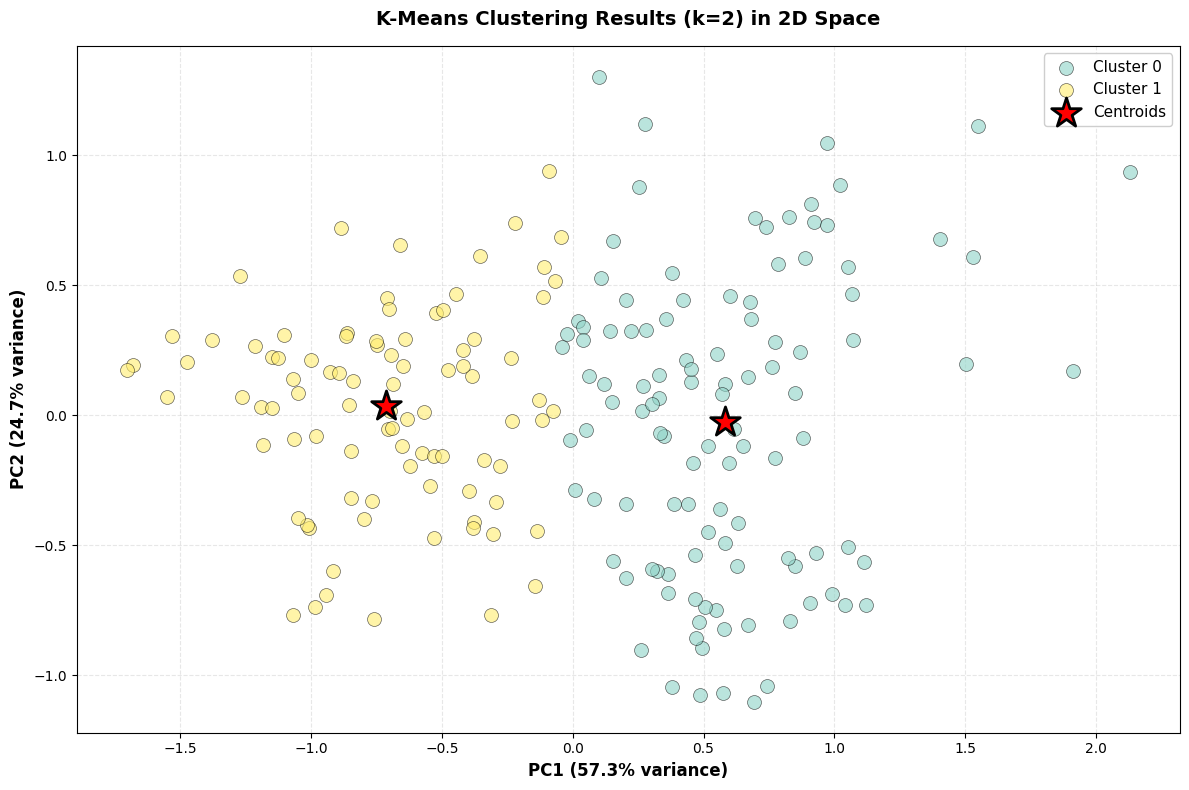

In [286]:

# Reduce to 2D using PCA for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_combined)

print(f"\nPCA Dimensionality Reduction:")
print(f"  Original dimensions: {X_combined.shape[1]}")
print(f"  Reduced dimensions: 2")
print(f"  Explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"  Total variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")

# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for clusters
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

# Plot clusters
for cluster_id in range(optimal_k):
    cluster_points = X_2d[labels_final == cluster_id]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
              c=[colors[cluster_id]], label=f'Cluster {cluster_id}',
              s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Transform cluster centers to 2D
centers_2d = pca_2d.transform(centers)

# Plot cluster centers
ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
          c='red', marker='*', s=500, edgecolors='black', linewidth=2,
          label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)',
              fontweight='bold', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)',
              fontweight='bold', fontsize=12)
ax.set_title(f'K-Means Clustering Results (k={optimal_k}) in 2D Space',
            fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 3.5: Clustering Summary
Generate final clustering summary.

In [287]:
summary_data = {
    'Metric': [
        'Optimal k (Silhouette)',
        'Optimal k (Elbow)',
        'Final Silhouette Score',
        'WCSS at optimal k',
        'Total samples clustered',
        'Variance explained (2D)',
        'PCA PC1 variance',
        'PCA PC2 variance'
    ],
    'Value': [
        f'{optimal_k_silhouette}',
        f'{optimal_k_elbow}',
        f'{final_silhouette:.4f}',
        f'{kmeans_final.inertia_:.2f}',
        f'{len(labels_final)}',
        f'{pca_2d.explained_variance_ratio_.sum():.2%}',
        f'{pca_2d.explained_variance_ratio_[0]:.4f}',
        f'{pca_2d.explained_variance_ratio_[1]:.4f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Silhouette analysis per sample
silhouette_vals = silhouette_samples(X_combined, labels_final)

print(f"\n\nPer-Cluster Silhouette Analysis:")
print("-" * 50)
for cluster_id in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[labels_final == cluster_id]
    print(f"  Cluster {cluster_id}:")
    print(f"    Mean silhouette: {cluster_silhouette_vals.mean():.4f}")
    print(f"    Min  silhouette: {cluster_silhouette_vals.min():.4f}")
    print(f"    Max  silhouette: {cluster_silhouette_vals.max():.4f}")




                 Metric  Value
 Optimal k (Silhouette)      2
      Optimal k (Elbow)      3
 Final Silhouette Score 0.3515
      WCSS at optimal k 117.62
Total samples clustered    200
Variance explained (2D) 81.96%
       PCA PC1 variance 0.5729
       PCA PC2 variance 0.2467


Per-Cluster Silhouette Analysis:
--------------------------------------------------
  Cluster 0:
    Mean silhouette: 0.3027
    Min  silhouette: -0.0664
    Max  silhouette: 0.4867
  Cluster 1:
    Mean silhouette: 0.4112
    Min  silhouette: 0.0685
    Max  silhouette: 0.5922
